# Hizli Test EDA

Tek dosya / ~100k satir ornek. Profesyonel analiz: `03_eda_cicids2018.ipynb` veya `04_eda_ciciot2023.ipynb`.


Kullanilan cloud CSV: Friday-02-03-2018_TrafficForML_CICFlowMeter.csv



--- Veri Temizligi ---
Ham boyut: (100000, 80)
Temizlenmis boyut: (99607, 80)
Silinen satir: 393

Eksik degeri en yuksek ilk 10 sutun:
                 missing_count  missing_ratio
Flow Pkts/s                393        0.00393
Flow Byts/s                393        0.00393
Dst Port                     0        0.00000
Protocol                     0        0.00000
Tot Fwd Pkts                 0        0.00000
Tot Bwd Pkts                 0        0.00000
Timestamp                    0        0.00000
Flow Duration                0        0.00000
Fwd Pkt Len Max              0        0.00000
Fwd Pkt Len Min              0        0.00000

--- Sinif Dengesi ---
Label
Benign    72034
Bot       27573
Name: count, dtype: int64

Binary dagilim:
Label
Benign    72034
Attack    27573
Name: count, dtype: int64

--- Outlier Analizi (IQR) ---
Bwd IAT Std          0.244601
Bwd IAT Max          0.243477
Bwd IAT Min          0.240134
Subflow Bwd Byts     0.230857
TotLen Bwd Pkts      0.230857
Pkt Len V

C:\Users\iakta\AppData\Local\Temp\ipykernel_9412\1421005336.py:192: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_in, y=target_col, order=order, palette="viridis")


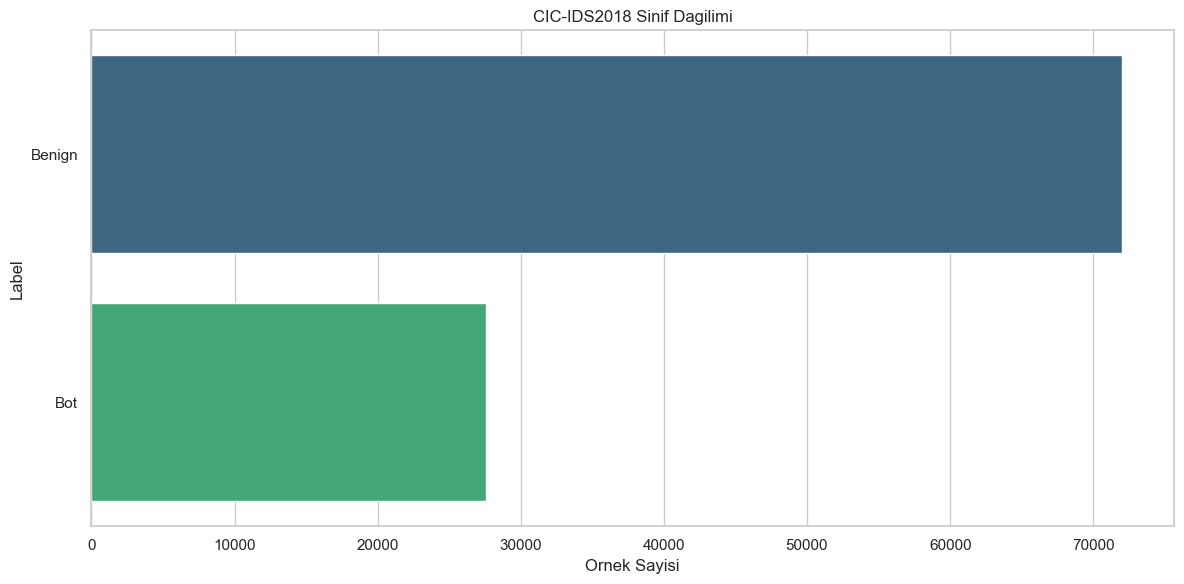

C:\Users\iakta\AppData\Local\Temp\ipykernel_9412\1421005336.py:207: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=labels, palette="Set2")


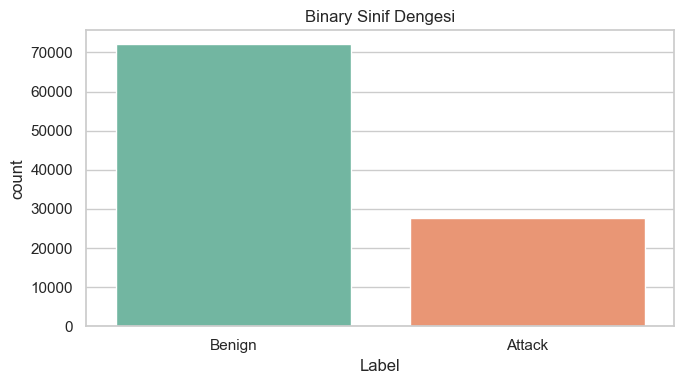

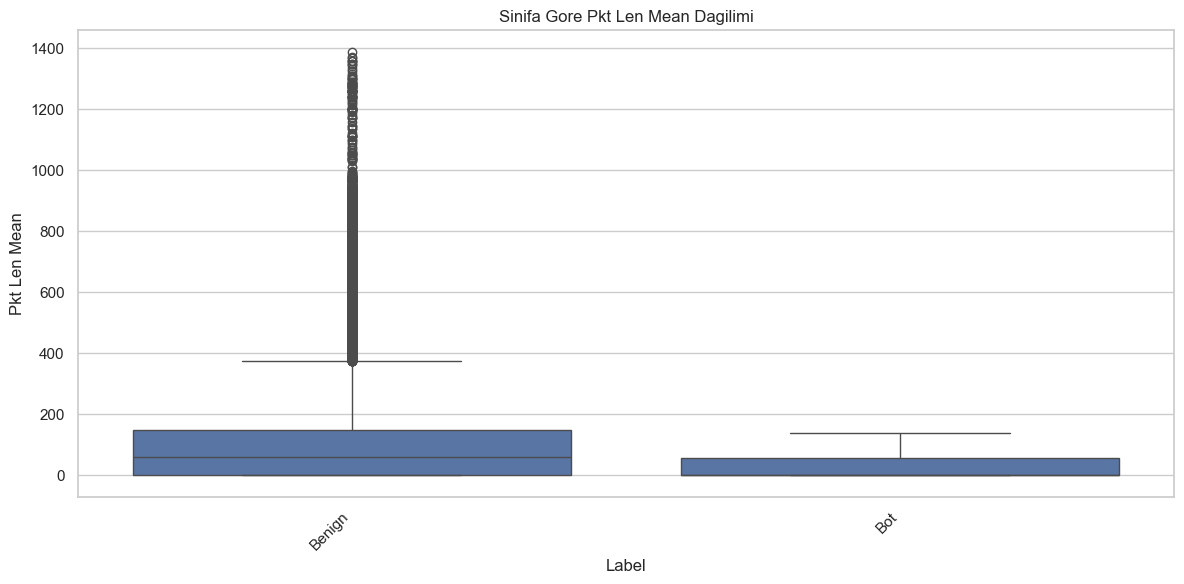

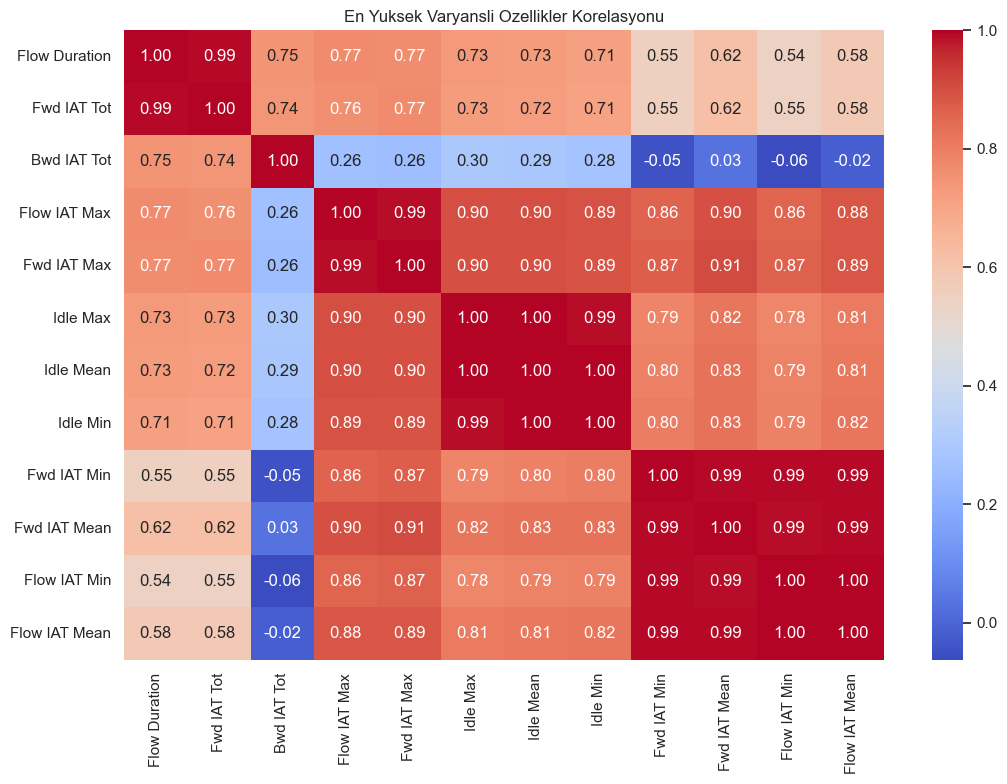

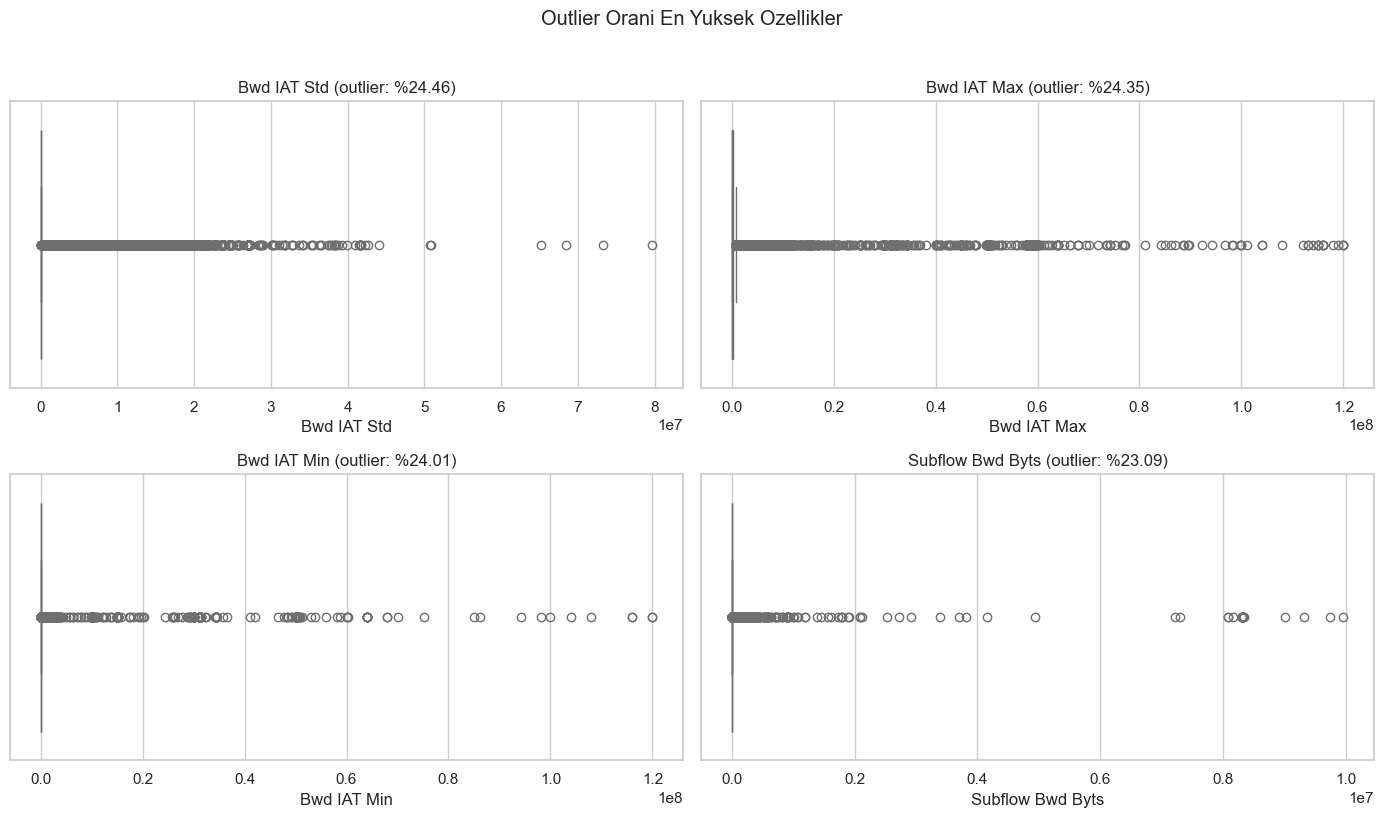

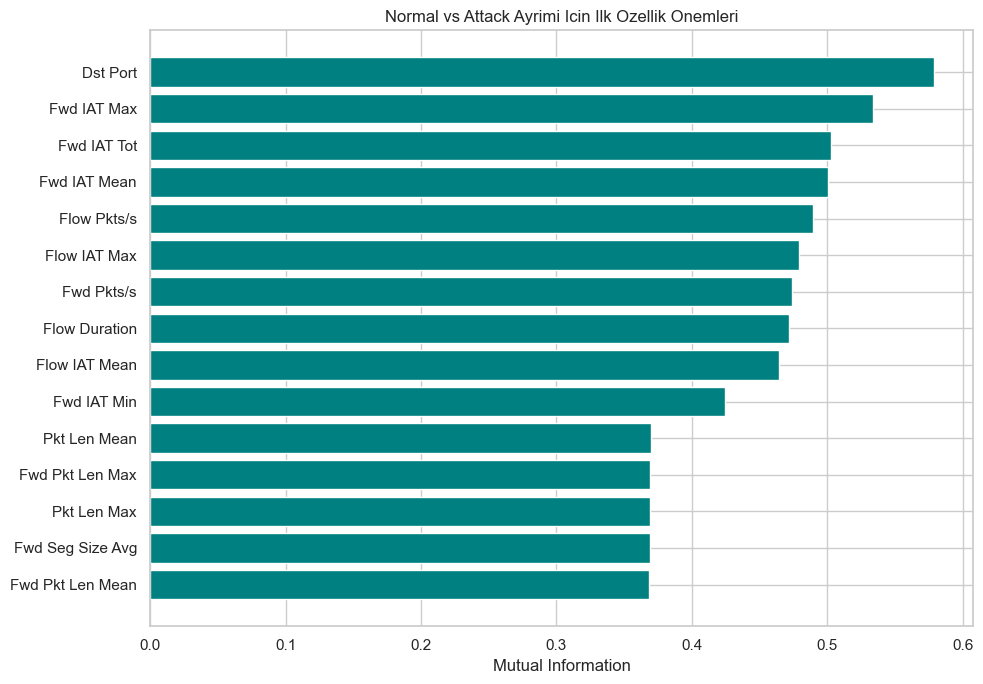

In [1]:
from pathlib import Path
from typing import Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

RANDOM_STATE = 42
MAX_ROWS = 100_000
TOP_CORR_FEATURES = 12
TOP_OUTLIER_FEATURES = 10
TOP_IMPORTANCE_FEATURES = 15
sns.set(style="whitegrid")


def find_project_root(start_path: Path) -> Path:
    """Find project root by searching configs/datasets.yaml.

    Args:
        start_path: Current working directory path.

    Returns:
        Project root path.

    Raises:
        FileNotFoundError: If project root is not found.
    """
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "configs" / "datasets.yaml").exists():
            return candidate
    raise FileNotFoundError("Project root bulunamadi.")


def resolve_cloud_csv(raw_dir: Path) -> Path:
    """Resolve cloud CSV with preferred Friday file fallback.

    Args:
        raw_dir: Raw cloud data directory.

    Returns:
        Selected CSV path.
    """
    csv_files = sorted(raw_dir.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"CSV bulunamadi: {raw_dir}")

    preferred_name = "Friday-02-03-2018_TrafficForML_CICFlowMeter.csv"
    preferred = [p for p in csv_files if p.name == preferred_name]
    return preferred[0] if preferred else csv_files[0]


def load_cloud_sample(root_dir: Path) -> pd.DataFrame:
    """Load sampled cloud dataframe.

    Args:
        root_dir: Project root path.

    Returns:
        Sampled dataframe.
    """
    raw_dir = root_dir / "data" / "raw" / "cicids2018"
    csv_path = resolve_cloud_csv(raw_dir)
    print(f"Kullanilan cloud CSV: {csv_path.name}")

    df_local = pd.read_csv(csv_path)
    sample_size = min(MAX_ROWS, len(df_local))
    return df_local.sample(n=sample_size, random_state=RANDOM_STATE)


def clean_dataframe(df_in: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Clean dataframe and produce missing-value report.

    Args:
        df_in: Raw dataframe.

    Returns:
        Tuple of cleaned dataframe and missing report.
    """
    df_copy = df_in.copy()
    df_copy.columns = df_copy.columns.str.strip()
    df_copy = df_copy.replace([np.inf, -np.inf], np.nan)

    missing = (
        df_copy.isna().sum().sort_values(ascending=False).rename("missing_count").to_frame()
    )
    missing["missing_ratio"] = missing["missing_count"] / len(df_copy)
    return df_copy.dropna(), missing


def resolve_packet_feature(df_in: pd.DataFrame) -> str | None:
    """Resolve packet-length-like feature name safely.

    Args:
        df_in: Input dataframe.

    Returns:
        Selected feature name or None.
    """
    lower_map = {c.lower(): c for c in df_in.columns}
    candidates = [
        "packet length mean",
        "pkt len mean",
        "totlen fwd pkts",
        "flow byts/s",
    ]
    direct = [lower_map[k] for k in candidates if k in lower_map]
    if direct:
        return direct[0]

    contains = [c for c in df_in.columns if "packet" in c.lower() and "mean" in c.lower()]
    if contains:
        return contains[0]

    numeric_cols = df_in.select_dtypes(include=[np.number]).columns.tolist()
    return numeric_cols[0] if numeric_cols else None


def build_binary_target(df_in: pd.DataFrame, target_col: str) -> pd.Series:
    """Build binary target benign=0 attack=1.

    Args:
        df_in: Input dataframe.
        target_col: Target column name.

    Returns:
        Binary target series.
    """
    label_series = df_in[target_col].astype(str).str.strip().str.lower()
    benign_aliases = {"benign", "normal"}
    return (~label_series.isin(benign_aliases)).astype(int)


def calculate_outlier_ratios(df_in: pd.DataFrame) -> pd.Series:
    """Calculate outlier ratio per numeric feature using IQR.

    Args:
        df_in: Input dataframe.

    Returns:
        Outlier ratio series sorted descending.
    """
    numeric_df = df_in.select_dtypes(include=[np.number])
    q1 = numeric_df.quantile(0.25)
    q3 = numeric_df.quantile(0.75)
    iqr = q3 - q1

    valid_cols = iqr[iqr > 0].index
    if len(valid_cols) == 0:
        return pd.Series(dtype=float)

    lower = q1[valid_cols] - 1.5 * iqr[valid_cols]
    upper = q3[valid_cols] + 1.5 * iqr[valid_cols]
    outlier_mask = (numeric_df[valid_cols] < lower) | (numeric_df[valid_cols] > upper)
    return outlier_mask.mean().sort_values(ascending=False)


def compute_feature_importance(df_in: pd.DataFrame, binary_target: pd.Series) -> pd.Series:
    """Compute first-look feature separability with mutual information.

    Args:
        df_in: Input dataframe.
        binary_target: Binary target series.

    Returns:
        Sorted MI score series.
    """
    numeric_df = df_in.select_dtypes(include=[np.number])
    if numeric_df.empty:
        return pd.Series(dtype=float)

    numeric_filled = numeric_df.fillna(numeric_df.median(numeric_only=True))
    scores = mutual_info_classif(
        numeric_filled,
        binary_target,
        random_state=RANDOM_STATE,
        discrete_features=False,
    )
    return pd.Series(scores, index=numeric_filled.columns).sort_values(ascending=False)


def plot_class_distribution(df_in: pd.DataFrame, target_col: str) -> None:
    """Plot multi-class class distribution.

    Args:
        df_in: Input dataframe.
        target_col: Label column.
    """
    plt.figure(figsize=(12, 6))
    order = df_in[target_col].value_counts().index
    sns.countplot(data=df_in, y=target_col, order=order, hue=target_col, palette="viridis", legend=False)
    plt.title("CIC-IDS2018 Sinif Dagilimi")
    plt.xlabel("Ornek Sayisi")
    plt.tight_layout()
    plt.show()


def plot_binary_distribution(binary_target: pd.Series) -> None:
    """Plot binary benign vs attack distribution.

    Args:
        binary_target: Binary target series.
    """
    labels = binary_target.map({0: "Benign", 1: "Attack"})
    plt.figure(figsize=(7, 4))
    sns.countplot(x=labels, hue=labels, palette="Set2", legend=False)
    plt.title("Binary Sinif Dengesi")
    plt.tight_layout()
    plt.show()


def plot_packet_feature_by_label(df_in: pd.DataFrame, target_col: str) -> None:
    """Plot boxplot for a packet-like feature by class.

    Args:
        df_in: Input dataframe.
        target_col: Label column.
    """
    feature_name = resolve_packet_feature(df_in)
    if feature_name is None:
        print("Uyari: Paket benzeri veya sayisal feature bulunamadi.")
        return

    top_labels = df_in[target_col].value_counts().head(8).index
    plot_df = df_in[df_in[target_col].isin(top_labels)]
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=plot_df, x=target_col, y=feature_name)
    plt.title(f"Sinifa Gore {feature_name} Dagilimi")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def plot_correlation_heatmap(df_in: pd.DataFrame) -> None:
    """Plot correlation heatmap using top variance features.

    Args:
        df_in: Input dataframe.
    """
    numeric_df = df_in.select_dtypes(include=[np.number])
    if numeric_df.shape[1] < 2:
        print("Uyari: Korelasyon icin yeterli sayisal feature yok.")
        return

    top_features = (
        numeric_df.var().sort_values(ascending=False).head(TOP_CORR_FEATURES).index
    )
    plt.figure(figsize=(11, 8))
    sns.heatmap(df_in[top_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("En Yuksek Varyansli Ozellikler Korelasyonu")
    plt.tight_layout()
    plt.show()


def plot_top_outlier_features(df_in: pd.DataFrame, outlier_ratios: pd.Series) -> None:
    """Plot boxplots for top outlier-heavy features.

    Args:
        df_in: Input dataframe.
        outlier_ratios: Outlier ratio series.
    """
    if outlier_ratios.empty:
        print("Uyari: Outlier analizi icin uygun feature yok.")
        return

    top_cols = outlier_ratios.head(4).index.tolist()
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    axes_flat = axes.flatten()
    for idx, col in enumerate(top_cols):
        sns.boxplot(x=df_in[col], ax=axes_flat[idx], color="skyblue")
        ratio = outlier_ratios[col] * 100
        axes_flat[idx].set_title(f"{col} (outlier: %{ratio:.2f})")

    for idx in range(len(top_cols), len(axes_flat)):
        axes_flat[idx].axis("off")

    plt.suptitle("Outlier Orani En Yuksek Ozellikler", y=1.02)
    plt.tight_layout()
    plt.show()


def plot_feature_importance(importance_scores: pd.Series) -> None:
    """Plot top feature importance snapshot.

    Args:
        importance_scores: MI score series.
    """
    if importance_scores.empty:
        print("Uyari: Feature importance hesaplanamadi.")
        return

    top_scores = importance_scores.head(TOP_IMPORTANCE_FEATURES).sort_values(ascending=True)
    plt.figure(figsize=(10, 7))
    plt.barh(top_scores.index, top_scores.values, color="teal")
    plt.title("Normal vs Attack Ayrimi Icin Ilk Ozellik Onemleri")
    plt.xlabel("Mutual Information")
    plt.tight_layout()
    plt.show()


project_root = find_project_root(Path.cwd())
cloud_df_raw = load_cloud_sample(project_root)
cloud_df, missing_report = clean_dataframe(cloud_df_raw)

if "Label" not in cloud_df.columns:
    raise KeyError("Label sutunu bulunamadi. CSV basliklarini kontrol et.")

binary_target = build_binary_target(cloud_df, target_col="Label")
outlier_ratios = calculate_outlier_ratios(cloud_df)
importance_scores = compute_feature_importance(cloud_df, binary_target)

print("\n--- Veri Temizligi ---")
print(f"Ham boyut: {cloud_df_raw.shape}")
print(f"Temizlenmis boyut: {cloud_df.shape}")
print(f"Silinen satir: {len(cloud_df_raw) - len(cloud_df)}")
print("\nEksik degeri en yuksek ilk 10 sutun:")
print(missing_report.head(10))

print("\n--- Sinif Dengesi ---")
print(cloud_df["Label"].value_counts().head(15))
print("\nBinary dagilim:")
print(binary_target.value_counts().rename(index={0: "Benign", 1: "Attack"}))

print("\n--- Outlier Analizi (IQR) ---")
print(outlier_ratios.head(TOP_OUTLIER_FEATURES))

print("\n--- Ayrim Gucu Yuksek Ozellikler ---")
print(importance_scores.head(TOP_IMPORTANCE_FEATURES))

plot_class_distribution(cloud_df, target_col="Label")
plot_binary_distribution(binary_target)
plot_packet_feature_by_label(cloud_df, target_col="Label")
plot_correlation_heatmap(cloud_df)
plot_top_outlier_features(cloud_df, outlier_ratios)
plot_feature_importance(importance_scores)
